In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("train.csv", usecols=['Age', 'Fare', 'Survived'])
df.tail()

,Survived,Age,Fare
886,0,27.0,13.00
887,1,19.0,30.00
888,0,NaN,23.45
889,1,26.0,30.00
890,0,32.0,7.75


In [3]:
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
dtype: float64

In [4]:
x = df.drop(columns=["Survived"])
y = df["Survived"]

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.2)

In [6]:
x_train["Age_imputed"] = x_train["Age"]
x_test["Age_imputed"] = x_test["Age"]

In [7]:
x_train.loc[x_train['Age_imputed'].isnull(), 'Age_imputed'] = x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values
x_test.loc[x_test['Age_imputed'].isnull(), 'Age_imputed'] = x_train['Age'].dropna().sample(x_test['Age'].isnull().sum()).values

In [8]:
x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values

array([36.  , 24.  ,  0.67, 31.  , 24.  ,  7.  , 25.  , 26.  , 42.  ,
       20.  , 25.  , 24.  , 16.  , 22.  , 38.  ,  5.  , 16.  , 19.  ,
       34.  , 17.  , 28.  , 58.  , 27.  , 46.  , 54.  , 65.  , 24.  ,
       24.  , 18.  , 11.  , 29.  , 46.  , 34.  , 31.  , 29.  , 44.  ,
       41.  , 33.  , 51.  , 56.  , 24.  , 28.  , 29.  , 29.  , 27.  ,
       43.  , 24.  , 34.  , 19.  ,  3.  , 19.  , 55.  , 30.  , 21.  ,
       28.  , 18.  , 36.  , 45.  ,  3.  , 45.  , 21.  , 17.  , 34.  ,
       28.  , 32.  , 47.  , 49.  , 30.  ,  8.  , 25.  , 25.  , 23.  ,
       21.  ,  3.  , 21.  , 31.  ,  0.83, 17.  , 16.  , 19.  ,  8.  ,
       43.  , 16.  , 55.  , 40.  , 48.  , 56.  , 59.  , 20.  , 30.  ,
       31.  , 25.  , 34.  , 31.  , 19.  , 17.  , 54.  ,  4.  , 80.  ,
       22.  , 43.  , 40.5 , 40.  , 14.  , 25.  , 16.  , 52.  , 24.  ,
       17.  , 42.  , 20.  , 60.  , 32.  ,  7.  , 32.  , 33.  , 33.  ,
       34.  , 35.  , 18.  , 27.  , 45.  , 23.  , 20.  , 31.  , 27.  ,
       35.  , 23.  ,

C:\Users\Chaittanya Navani\AppData\Local\Temp\ipykernel_2980\3925229177.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'],label='Original',hist=False)
C:\Users\Chaittanya Navani\AppData\Local\Temp\ipykernel_2980\3925229177.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

 

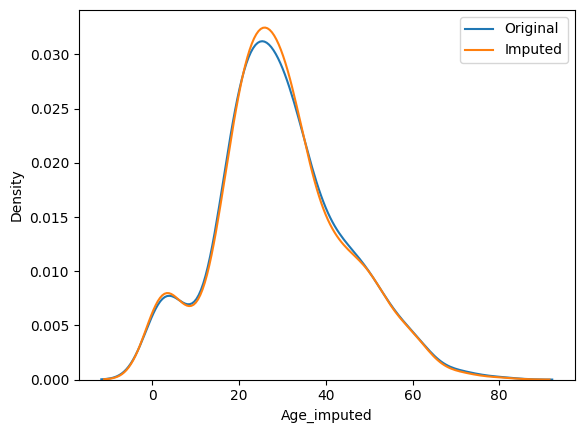

In [9]:
sns.distplot(x_train['Age'],label='Original',hist=False)
sns.distplot(x_train['Age_imputed'],label = 'Imputed',hist=False)

plt.legend()
plt.show()

In [10]:
print('Original variable variance: ', x_train['Age'].var())
print('Variance after random imputation: ', x_train['Age_imputed'].var())

Original variable variance:  210.2517072477435
Variance after random imputation:  206.35760401634033


In [11]:
x_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2700.831981,71.580633,49.341065
Age,71.580633,210.251707,210.251707
Age_imputed,49.341065,210.251707,206.357604


<Axes: >

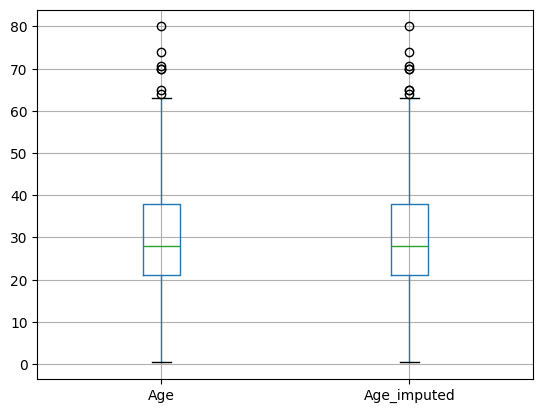

In [12]:
x_train[['Age', 'Age_imputed']].boxplot()

In [13]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [14]:
data.isna().mean()

FireplaceQu    0.472603
GarageQual     0.055479
SalePrice      0.000000
dtype: float64

In [15]:
x = data
y = data["SalePrice"]

In [16]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [17]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [18]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
671,NaN,TA,103600,TA,NaN
270,Gd,TA,266000,TA,Gd
733,TA,TA,131400,TA,TA
539,TA,TA,272000,TA,TA
198,NaN,NaN,104000,NaN,NaN


In [21]:
X_train.loc[X_train['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test.loc[X_test['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train.loc[X_train['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test.loc[X_test['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

In [36]:
temp = pd.concat(
    [
        X_train["GarageQual"].value_counts() / len(X_train["GarageQual"].dropna()), 
        X_train["GarageQual_imputed"].value_counts() / len(X_train["GarageQual"])
    ], axis=1
)
temp.columns = ["Original", "Imputed"]
temp

,Original,Imputed
TA,0.951043,0.950342
Fa,0.037171,0.038527
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [37]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.644220
TA,0.412439,0.542088
Fa,0.040917,0.052750
Po,0.027823,0.038159
Ex,0.024550,0.033670


C:\Users\Chaittanya Navani\AppData\Local\Temp\ipykernel_2980\1827688635.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
C:\Users\Chaittanya Navani\AppData\Local\Temp\ipykernel_2980\1827688635.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwa

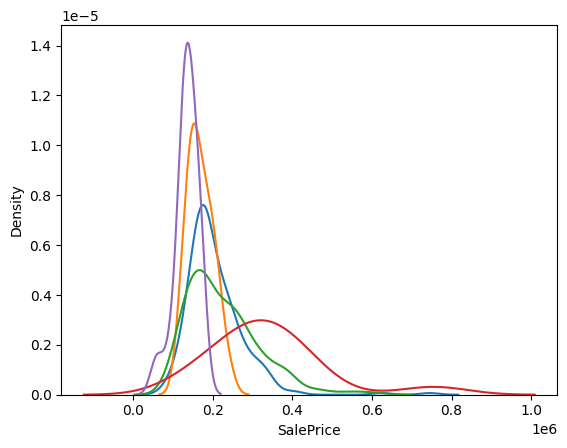

In [44]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
plt.show()

C:\Users\Chaittanya Navani\AppData\Local\Temp\ipykernel_2980\722808554.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
C:\Users\Chaittanya Navani\AppData\Local\Temp\ipykernel_2980\722808554.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.c

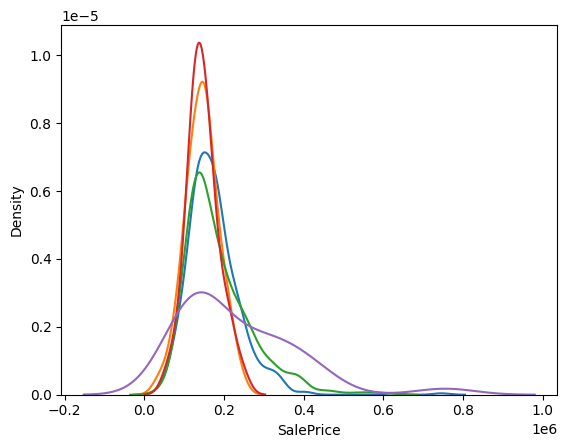

In [45]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
plt.show()